# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

print("Library Imported")

Library Imported


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
# dataset dummy
def generate_mock_data(num_samples=5000):
    np.random.seed(42)
    data = {
        'customer_id': range(1001, 1001 + num_samples),
        'age': np.random.randint(20, 65, size=num_samples),
        'income': np.random.randint(3000000, 30000000, size=num_samples),
        'loan_amount': np.random.randint(5000000, 50000000, size=num_samples),
        'credit_score': np.random.randint(300, 850, size=num_samples),
        'employment_type': np.random.choice(['Full-Time', 'Part-Time', 'Self-Employed', 'Unemployed'], size=num_samples),
        'risk_rating': np.random.choice([0, 1], size=num_samples, p=[0.7, 0.3]) # Target (SINKRON!)
    }

    df = pd.DataFrame(data)

    # add missing value
    df.loc[df.sample(frac=0.04).index, 'income'] = np.nan
    df.loc[df.sample(frac=0.03).index, 'credit_score'] = np.nan

    # add duplicate
    duplicate_rows = df.sample(n=25, random_state=42)
    df = pd.concat([df, duplicate_rows], ignore_index=True)

    return df

# directory
os.makedirs('namadataset_raw', exist_ok=True)
raw_data_path = 'namadataset_raw/credit_data.csv'

# Generate + save
df_raw = generate_mock_data(num_samples=5000)
df_raw.to_csv(raw_data_path, index=False)

print(f"Dataset dummy berhasil dibuat! Total baris setelah duplikasi: {len(df_raw)}")
print(df_raw.head())

Dataset dummy berhasil dibuat! Total baris setelah duplikasi: 5025
   customer_id  age      income  loan_amount  credit_score employment_type  \
0         1001   58  25451154.0     27907093         712.0       Part-Time   
1         1002   48  11009292.0     44660093         490.0       Full-Time   
2         1003   34   8108728.0     12142727         441.0   Self-Employed   
3         1004   62  24838011.0     17067196         372.0       Part-Time   
4         1005   27         NaN     41158112         466.0       Full-Time   

   risk_rating  
0            0  
1            0  
2            0  
3            1  
4            0  


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5025 entries, 0 to 5024
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      5025 non-null   int64  
 1   age              5025 non-null   int64  
 2   income           4824 non-null   float64
 3   loan_amount      5025 non-null   int64  
 4   credit_score     4875 non-null   float64
 5   employment_type  5025 non-null   object 
 6   risk_rating      5025 non-null   int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 274.9+ KB
None

=== Jumlah Missing Values ===
customer_id          0
age                  0
income             201
loan_amount          0
credit_score       150
employment_type      0
risk_rating          0
dtype: int64

=== Jumlah Data Duplikat ===
Total baris duplikat: 25


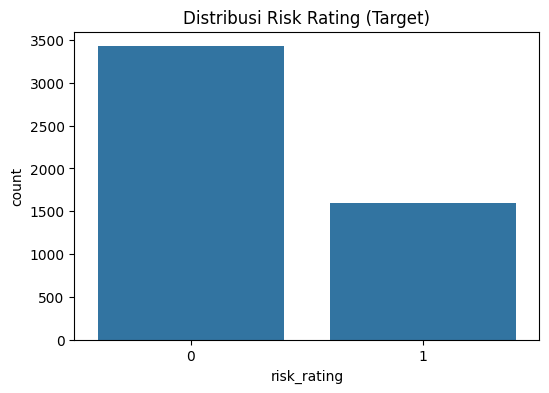

In [4]:
# cek struktur data
print("=== Informasi Dataset ===")
print(df_raw.info())

# cek missing values
print("\n=== Jumlah Missing Values ===")
print(df_raw.isnull().sum())

# cek data duplikat
print("\n=== Jumlah Data Duplikat ===")
print(f"Total baris duplikat: {df_raw.duplicated().sum()}")

# distribusi target label
plt.figure(figsize=(6, 4))
sns.countplot(data=df_raw, x='risk_rating')
plt.title('Distribusi Risk Rating (Target)')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [5]:
def preprocess_data(input_path, output_dir):
    # Load data
    df = pd.read_csv(input_path)

    # data duplicate drop
    df = df.drop_duplicates()

    # fill missing value
    df['income'] = df['income'].fillna(df['income'].median())
    df['credit_score'] = df['credit_score'].fillna(df['credit_score'].mean())

    # encoding data
    le = LabelEncoder()
    df['employment_type'] = le.fit_transform(df['employment_type'])

    # normalisasi
    scaler = StandardScaler()
    features_to_scale = ['age', 'income', 'loan_amount', 'credit_score']
    df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

    # Drop kolom tidak penting (untuk training)
    df = df.drop(columns=['customer_id'])

    # save
    os.makedirs(output_dir, exist_ok=True)
    processed_path = os.path.join(output_dir, 'credit_data_processed.csv')
    df.to_csv(processed_path, index=False)

    print(f"Data preprocessing selesai! Disimpan di: {processed_path}")
    return df

# eksekusi fungsi preprocessing
output_preprocessed_dir = 'namadataset_preprocessing'
df_processed = preprocess_data(raw_data_path, output_preprocessed_dir)
print(df_processed.head())

Data preprocessing selesai! Disimpan di: namadataset_preprocessing/credit_data_processed.csv
        age    income  loan_amount  credit_score  employment_type  risk_rating
0  1.230639  1.175853     0.042225      0.891742                1            0
1  0.454964 -0.693809     1.338906     -0.529586                0            0
2 -0.630980 -1.069320    -1.177936     -0.843303                2            0
3  1.540909  1.096475    -0.796783     -1.285067                1            1
4 -1.173953 -0.005643     1.067853     -0.683243                0            0


In [6]:
!mkdir -p .github/workflows